In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import numpy as np
import os

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

Using device: cuda


In [5]:
data_path = './data'
if os.path.exists(data_path) == False or os.path.isdir(data_path) == False:
    download = True
else:
    download = False
train_dataset_without_transform = torchvision.datasets.MNIST(
    root=data_path, 
    train=True, 
    download=download
    )

Text(0.5, 1.0, 'Sample Image - Label: 5')

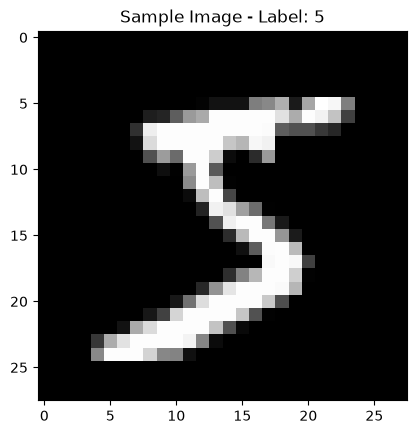

In [6]:
sample_image, sample_label = train_dataset_without_transform[0]

plt.imshow(sample_image, cmap='gray')
plt.title(f'Sample Image - Label: {sample_label}')

In [7]:
print(f'Sample Image Shape: {sample_image.size}')

Sample Image Shape: (28, 28)


In [8]:
# Transformation
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)) # MNIST dataset mean and std
])

In [9]:
train_dataset = torchvision.datasets.MNIST(
    root=data_path, 
    train=True,  
    download=download,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root=data_path,
    train=False,
    download=download,
    transform=transform
)

In [10]:
train_dataset

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.1307,), std=(0.3081,))
           )

In [11]:
test_dataset

Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.1307,), std=(0.3081,))
           )

In [12]:
train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=64,
    shuffle=True
)

test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_size=1000,
    shuffle=False
)

In [13]:
class LinearClassifier(nn.Module):
    def __init__(self):
        super(LinearClassifier, self).__init__()
        self.flatten = nn.Flatten()
        self.linear = nn.Sequential(
            nn.Linear(28*28, 128), # First Hidden Layer, input = 28x28, output = 128
            nn.ReLU(), # First Hidden layer activation
            nn.Linear(128, 10) # Output layer, input = 128, output = 10 (for 10 classes)
        )

    def forward(self, x):
        x = self.flatten(x)
        x = self.linear(x)
        return x

In [14]:
# Initialize the model, loss function, and optimizer
model = LinearClassifier()
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [15]:
def train_epoch(model, train_dataloader, loss_function, optimizer, device):
    # Move model to the specified device
    model = model.to(device)
    # Set the model to training mode
    model.train()

    # Initial epoch loss for entire batch
    epoch_loss = 0.0

    # Initialize loss for each sample in the batch
    running_loss = 0.0
    correct_prediction = 0
    total_prediction = 0
    total_batches = len(train_dataloader)

    for batch_idx, (data, target) in enumerate(train_dataloader):
        # Move data and target to the specified device
        data, target = data.to(device), target.to(device)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        output = model(data)

        # Calculate loss
        loss = loss_function(output, target)

        # Backward pass
        loss.backward()

        # Update weights
        optimizer.step()

        # Update running loss and correct predictions
        running_loss += loss.item()
        epoch_loss += loss.item()

        _, predicted = output.max(dim=1)
        total_prediction += target.size(0)
        correct_prediction += (predicted == target).sum().item()

        if (batch_idx + 1) % 100 == 0 or (batch_idx + 1) == total_batches:
            avg_loss = running_loss / 100
            accuracy = 100.0 * correct_prediction / total_prediction
            print(f'\tBatch: {batch_idx + 1}, Average Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%')

            # Reset running loss and correct predictions 
            running_loss = 0.0
            correct_prediction = 0
            total_prediction = 0
    
    avg_epoch_loss = epoch_loss / total_batches
    return model, avg_epoch_loss

In [16]:
def evaluate(model, test_dataloader, device):
    # Move model to the specified device
    model = model.to(device)
    # Set the model to evaluation mode
    model.eval()

    correct_prediction = 0
    total_prediction = 0

    with torch.no_grad():
        for data, target in test_dataloader:
            # Move data and target to the specified device
            data, target = data.to(device), target.to(device)

            # Forward pass
            output = model(data)

            # Get predictions
            _, predicted = output.max(dim=1)
            total_prediction += target.size(0)
            correct_prediction += (predicted == target).sum().item()

    accuracy = 100.0 * correct_prediction / total_prediction
    print(f'\tTest Accuracy: {accuracy:.2f}%')
    return accuracy

In [17]:
num_epochs = 5

train_losses = []
test_accuracies = []

for epoch in range(num_epochs):
    print(f'\n[Training]Epoch {epoch + 1}/{num_epochs}')
    model, avg_epoch_loss = train_epoch(model, train_dataloader, loss_function, optimizer, device)
    train_losses.append(avg_epoch_loss)

    print(f'[Testing]Epoch {epoch + 1}/{num_epochs}')
    test_accuracy = evaluate(model, test_dataloader, device)
    test_accuracies.append(test_accuracy)


[Training]Epoch 1/5
	Batch: 100, Average Loss: 0.6220, Accuracy: 82.17%
	Batch: 200, Average Loss: 0.3249, Accuracy: 90.64%
	Batch: 300, Average Loss: 0.2700, Accuracy: 91.91%
	Batch: 400, Average Loss: 0.2465, Accuracy: 92.55%
	Batch: 500, Average Loss: 0.1993, Accuracy: 94.25%
	Batch: 600, Average Loss: 0.1948, Accuracy: 94.52%
	Batch: 700, Average Loss: 0.1590, Accuracy: 95.03%
	Batch: 800, Average Loss: 0.1643, Accuracy: 95.09%
	Batch: 900, Average Loss: 0.1458, Accuracy: 95.53%
	Batch: 938, Average Loss: 0.0494, Accuracy: 96.17%
[Testing]Epoch 1/5
	Test Accuracy: 96.02%

[Training]Epoch 2/5
	Batch: 100, Average Loss: 0.1369, Accuracy: 96.02%
	Batch: 200, Average Loss: 0.1252, Accuracy: 96.27%
	Batch: 300, Average Loss: 0.1073, Accuracy: 96.75%
	Batch: 400, Average Loss: 0.1097, Accuracy: 96.70%
	Batch: 500, Average Loss: 0.1100, Accuracy: 96.88%
	Batch: 600, Average Loss: 0.1159, Accuracy: 96.47%
	Batch: 700, Average Loss: 0.1214, Accuracy: 96.31%
	Batch: 800, Average Loss: 0.101

Text(0, 0.5, 'Accuracy (%)')

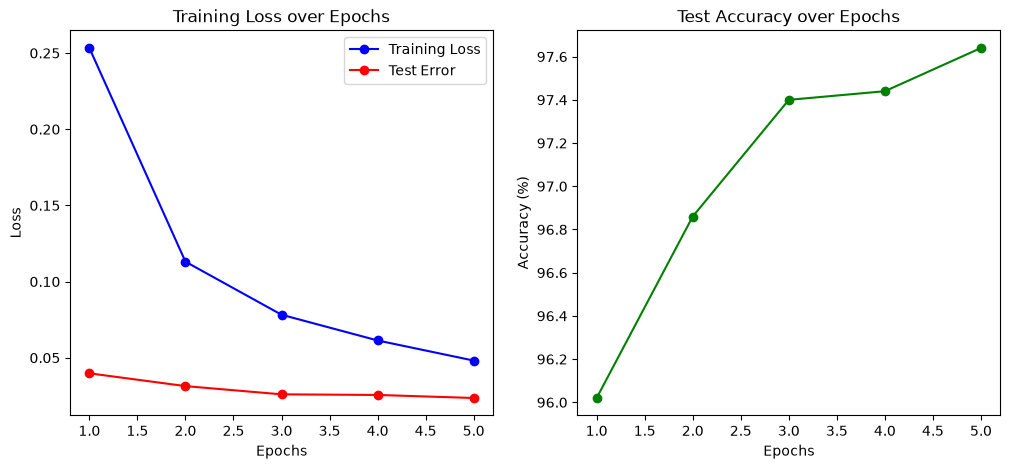

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
# Plot training loss
ax[0].plot(range(1, num_epochs + 1), train_losses, marker='o', color='blue', label='Training Loss')
ax[0].plot(range(1, num_epochs + 1), (100.0 - np.array(test_accuracies))/100.0, marker='o', color='red', label='Test Error')
ax[0].set_title('Training Loss over Epochs')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].legend()

# Plot test accuracy
ax[1].plot(range(1, num_epochs + 1), test_accuracies, marker='o', color='green')
ax[1].set_title('Test Accuracy over Epochs')    
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy (%)')